In [1]:
# ============================================================
# MODEL_SELECTION_AND_TUNING.ipynb
# AI-BASED INSTAGRAM ENGAGEMENT PREDICTION SYSTEM
# ============================================================

import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("=" * 70)
print("MODEL SELECTION AND TUNING")
print("=" * 70)

MODEL SELECTION AND TUNING


In [2]:
# ============================================================
# LOAD PREPARED DATASET
# ============================================================

DATA_PATH = (
    r"D:\newwwwwwww\AiBasedInstagramPrediction"
    r"\datasets\final_eda_dataset.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

display(df.head())

Dataset loaded successfully.
Rows    : 100,000
Columns : 62


,post_id,account_id,category,account_type,follower_count,following_count,account_age_days,verified_status,posting_frequency,average_historical_engagement,audience_growth_rate,account_activity_level,content_consistency,caption,caption_length,word_count,sentence_count,hashtags,hashtag_count,unique_hashtag_count,average_hashtag_length,hashtag_character_count,emoji_count,mention_count,question_mark_count,exclamation_count,uppercase_ratio,numeric_token_count,url_present,call_to_action,caption_sentiment,caption_subjectivity,caption_readability,keyword_density,caption_complexity,caption_engagement_intent,posting_datetime,posting_hour,day_of_week,is_weekend,posting_time_period,media_type,has_image,has_location,has_mention,sponsored,content_originality,content_quality_score,creator_activity_score,image_width,image_height,aspect_ratio,brightness,contrast,saturation,sharpness,colorfulness,face_count,text_in_image,visual_complexity,estimated_image_quality,performance_class
0,POST_00000000,ACC_003617,Education,Business,2272,1269,1010,False,7.87,0.027265,0.007115,0.819569,0.552542,Study method that improved retention more than...,88,14,2,#onlinelearning #reels #study #student #instag...,7,7,8.86,62,0,0,0,0,0.0274,0,0,1,-0.0301,0.0,63.11,1.0,1.0,0.3000,2024-06-30 19:24:00,19,Friday,False,Evening,Reel,True,True,True,False,0.5894,0.5702,0.6010,1080.0,1920.0,0.562,0.484,0.697,0.423,0.320,0.599,2.0,0.0,0.327,0.650,High
1,POST_00000001,ACC_000534,Technology,Personal,267,372,2767,False,2.60,0.041254,0.021205,0.678328,0.979273,Workflow change that reduced context switching...,118,15,3,#programming #opensource #love #datascience #p...,6,5,10.50,63,0,0,0,0,0.0297,0,0,1,0.1931,0.0,33.83,1.0,1.0,0.4500,2023-10-12 06:31:00,6,Thursday,False,Early Morning,Reel,True,True,False,False,0.7678,0.6002,0.6034,1920.0,1080.0,1.778,0.680,0.775,0.260,0.784,0.612,0.0,0.0,0.122,0.682,Medium
2,POST_00000002,ACC_006323,Entertainment,Creator,7642,1225,1437,False,2.04,0.016957,-0.007703,0.638118,0.514295,✨ Comedy special that made me laugh out loud m...,62,11,2,#reels #cinema #popculture #beautiful #soundtr...,8,7,7.88,63,2,0,0,0,0.0213,0,0,0,0.0584,0.0,93.58,1.0,1.0,0.0667,2024-06-09 13:05:00,13,Saturday,True,Afternoon,Photo,True,False,False,False,0.3627,0.6231,0.6573,720.0,900.0,0.800,0.423,0.356,0.362,0.563,0.755,1.0,0.0,0.411,0.640,Medium
3,POST_00000003,ACC_009502,Education,Creator,3880,1187,2569,False,8.76,0.017244,-0.001001,0.596080,0.248969,Quick framework for approaching complex topics...,53,6,2,#academic #knowledge #edtech #study #love #ins...,7,7,8.00,56,3,0,0,0,0.0244,0,0,0,0.2256,0.0,34.59,1.0,1.0,0.2500,2024-09-27 18:55:00,18,Monday,False,Evening,Reel,True,True,False,False,0.2000,0.4906,0.5298,1920.0,3413.0,0.563,NaN,0.527,0.447,0.394,0.777,1.0,0.0,0.197,0.601,Low
4,POST_00000004,ACC_002845,Education,Personal,2104,521,305,False,7.29,0.014833,-0.024059,0.287589,0.434544,Simple breakdown of note systems that finally ...,63,10,2,#lifelonglearning #onlinelearning #studygram #...,6,6,11.83,71,1,0,0,0,0.0196,0,0,0,-0.0419,0.0,74.86,1.0,1.0,0.0333,2024-11-09 13:46:00,13,Saturday,True,Afternoon,Photo,True,True,False,False,0.2987,0.5499,0.3483,1440.0,810.0,1.778,0.581,0.602,0.623,0.570,0.263,3.0,0.0,0.505,0.649,Low


In [3]:
# ============================================================
# DEFINE TARGET VARIABLE
# ============================================================

TARGET = "performance_class"

if TARGET not in df.columns:
    raise ValueError(f"Target variable '{TARGET}' was not found.")

print("Target variable:", TARGET)

print("\nTarget distribution:")
display(
    df[TARGET]
    .value_counts()
    .to_frame("Count")
)

print("\nTarget percentages:")
display(
    (df[TARGET].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("Percentage")
)

Target variable: performance_class

Target distribution:


,Count
performance_class,
Medium,36000
High,32000
Low,32000



Target percentages:


,Percentage
performance_class,
Medium,36.0
High,32.0
Low,32.0


In [4]:
# ============================================================
# REMOVE NON-PREDICTIVE RAW FIELDS
# ============================================================

non_predictive_columns = [
    "post_id",
    "account_id",
    "caption",
    "hashtags",
    "posting_datetime"
]

columns_to_remove = [
    col for col in non_predictive_columns
    if col in df.columns
]

df_model = df.drop(columns=columns_to_remove)

print("Removed columns:")
for col in columns_to_remove:
    print("-", col)

print(f"\nRemaining columns: {df_model.shape[1]}")

Removed columns:
- post_id
- account_id
- caption
- hashtags
- posting_datetime

Remaining columns: 57


In [5]:
# ============================================================
# SEPARATE FEATURES AND TARGET
# ============================================================

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature data types:")
display(
    X.dtypes.value_counts()
)

Feature matrix shape: (100000, 56)
Target shape: (100000,)

Feature data types:


float64    28
int64      17
bool        6
str         5
Name: count, dtype: int64

In [6]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTesting set:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training set:
X_train: (80000, 56)
y_train: (80000,)

Testing set:
X_test: (20000, 56)
y_test: (20000,)


In [7]:
# ============================================================
# IDENTIFY FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "bool", "category"]
).columns.tolist()

print("=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print(f"\nNumerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

FEATURE TYPES

Numerical features   : 45
Categorical features : 11

Categorical features:
- category
- account_type
- verified_status
- day_of_week
- is_weekend
- posting_time_period
- media_type
- has_image
- has_location
- has_mention
- sponsored


In [8]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [9]:
# ============================================================
# BASELINE MODEL DEVELOPMENT
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Machine Learning models and evaluation metrics imported.")

Machine Learning models and evaluation metrics imported.


In [10]:
# ============================================================
# DEFINE BASELINE MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradient Boosting": HistGradientBoostingClassifier(
        max_iter=100,
        random_state=42
    )
}

print("Models selected for baseline comparison:")

for name in models:
    print("-", name)

Models selected for baseline comparison:
- Logistic Regression
- Random Forest
- Extra Trees
- HistGradient Boosting


In [11]:
# ============================================================
# TRAIN AND EVALUATE BASELINE MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print(f"TRAINING: {name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = pipeline

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

print("\nBaseline model training completed.")


TRAINING: Logistic Regression


ValueError: Cannot use most_frequent strategy with non-numeric data:
could not convert string to float: 'Food'

In [12]:
# ============================================================
# CHECK FEATURE TYPES
# ============================================================

print("=" * 70)
print("CHECKING FEATURE TYPES")
print("=" * 70)

print("\nNumerical features:")
for feature in numeric_features:
    print("-", feature)

print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

print("\nActual object/string columns in X_train:")
print(
    X_train.select_dtypes(include=["object"]).columns.tolist()
)

CHECKING FEATURE TYPES

Numerical features:
- follower_count
- following_count
- account_age_days
- posting_frequency
- average_historical_engagement
- audience_growth_rate
- account_activity_level
- content_consistency
- caption_length
- word_count
- sentence_count
- hashtag_count
- unique_hashtag_count
- average_hashtag_length
- hashtag_character_count
- emoji_count
- mention_count
- question_mark_count
- exclamation_count
- uppercase_ratio
- numeric_token_count
- url_present
- call_to_action
- caption_sentiment
- caption_subjectivity
- caption_readability
- keyword_density
- caption_complexity
- caption_engagement_intent
- posting_hour
- content_originality
- content_quality_score
- creator_activity_score
- image_width
- image_height
- aspect_ratio
- brightness
- contrast
- saturation
- sharpness
- colorfulness
- face_count
- text_in_image
- visual_complexity
- estimated_image_quality

Categorical features:
- category
- account_type
- verified_status
- day_of_week
- is_weekend
- pos

In [13]:
# ============================================================
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

# Categorical columns include strings, booleans and category dtype
categorical_features = X_train.select_dtypes(
    include=["object", "bool", "category"]
).columns.tolist()

# Numerical columns are strictly numeric
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print(f"\nNumerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

FEATURE TYPES

Numerical features   : 45
Categorical features : 11

Categorical features:
- category
- account_type
- verified_status
- day_of_week
- is_weekend
- posting_time_period
- media_type
- has_image
- has_location
- has_mention
- sponsored


In [14]:
# ============================================================
# UPDATED PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Updated preprocessing pipeline created successfully.")

Updated preprocessing pipeline created successfully.


In [15]:
# ============================================================
# TEST PREPROCESSING
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)

print("Preprocessing completed successfully.")
print(f"Original training features : {X_train.shape[1]}")
print(f"Processed training features: {X_train_processed.shape[1]}")

ValueError: Cannot use most_frequent strategy with non-numeric data:
could not convert string to float: 'Food'

In [16]:
# ============================================================
# ROBUST FEATURE TYPE DETECTION AND PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Detect feature types directly from X_train
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("=" * 70)
print("FEATURE TYPE VERIFICATION")
print("=" * 70)

print(f"Numerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\nCategorical features:")
for feature in categorical_features:
    print(f"  - {feature}")

# Check that every feature belongs to exactly one group
all_detected_features = numeric_features + categorical_features

missing_features = [
    col for col in X_train.columns
    if col not in all_detected_features
]

duplicate_features = [
    col for col in X_train.columns
    if (col in numeric_features and col in categorical_features)
]

print("\nFeature verification:")
print(f"Total X_train features : {X_train.shape[1]}")
print(f"Detected features      : {len(all_detected_features)}")
print(f"Unclassified features  : {len(missing_features)}")
print(f"Duplicate assignments  : {len(duplicate_features)}")

if missing_features:
    print("\nUnclassified:")
    print(missing_features)

if duplicate_features:
    print("\nDuplicate assignments:")
    print(duplicate_features)

# ============================================================
# PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("\nPreprocessing pipeline created successfully.")

FEATURE TYPE VERIFICATION
Numerical features   : 45
Categorical features : 11

Categorical features:
  - category
  - account_type
  - verified_status
  - day_of_week
  - is_weekend
  - posting_time_period
  - media_type
  - has_image
  - has_location
  - has_mention
  - sponsored

Feature verification:
Total X_train features : 56
Detected features      : 56
Unclassified features  : 0
Duplicate assignments  : 0

Preprocessing pipeline created successfully.


In [17]:
# ============================================================
# TEST PREPROCESSING
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("=" * 70)
print("PREPROCESSING TEST")
print("=" * 70)

print(f"Original training features : {X_train.shape[1]}")
print(f"Processed training features: {X_train_processed.shape[1]}")

print(f"\nOriginal testing features  : {X_test.shape[1]}")
print(f"Processed testing features : {X_test_processed.shape[1]}")

print("\nPreprocessing completed successfully.")

ValueError: Cannot use most_frequent strategy with non-numeric data:
could not convert string to float: 'Food'

In [18]:
# ============================================================
# EXPLICIT FEATURE TYPE DEFINITION
# ============================================================

categorical_features = [
    "category",
    "account_type",
    "verified_status",
    "day_of_week",
    "is_weekend",
    "posting_time_period",
    "media_type",
    "has_image",
    "has_location",
    "has_mention",
    "sponsored"
]

# Keep only columns that actually exist in X_train
categorical_features = [
    col for col in categorical_features
    if col in X_train.columns
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("=" * 70)
print("FEATURE TYPE DEFINITION")
print("=" * 70)

print(f"\nTotal features       : {len(X_train.columns)}")
print(f"Numerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\nCategorical features:")
for col in categorical_features:
    print(" -", col)

print("\nNumerical features:")
for col in numeric_features:
    print(" -", col)

FEATURE TYPE DEFINITION

Total features       : 56
Numerical features   : 45
Categorical features : 11

Categorical features:
 - category
 - account_type
 - verified_status
 - day_of_week
 - is_weekend
 - posting_time_period
 - media_type
 - has_image
 - has_location
 - has_mention
 - sponsored

Numerical features:
 - follower_count
 - following_count
 - account_age_days
 - posting_frequency
 - average_historical_engagement
 - audience_growth_rate
 - account_activity_level
 - content_consistency
 - caption_length
 - word_count
 - sentence_count
 - hashtag_count
 - unique_hashtag_count
 - average_hashtag_length
 - hashtag_character_count
 - emoji_count
 - mention_count
 - question_mark_count
 - exclamation_count
 - uppercase_ratio
 - numeric_token_count
 - url_present
 - call_to_action
 - caption_sentiment
 - caption_subjectivity
 - caption_readability
 - keyword_density
 - caption_complexity
 - caption_engagement_intent
 - posting_hour
 - content_originality
 - content_quality_score
 -

In [19]:
# ============================================================
# REBUILD PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline rebuilt successfully.")

Preprocessing pipeline rebuilt successfully.


In [20]:
# ============================================================
# TEST PREPROCESSING
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("=" * 70)
print("PREPROCESSING TEST")
print("=" * 70)

print(f"Original training features : {X_train.shape[1]}")
print(f"Processed training features: {X_train_processed.shape[1]}")

print(f"\nOriginal testing features  : {X_test.shape[1]}")
print(f"Processed testing features : {X_test_processed.shape[1]}")

print("\n✓ Preprocessing completed successfully.")

ValueError: Cannot use most_frequent strategy with non-numeric data:
could not convert string to float: 'Food'

In [21]:
# ============================================================
# FINAL CLEAN PREPROCESSING SETUP
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Explicit categorical features
# ------------------------------------------------------------

categorical_features = [
    "category",
    "account_type",
    "verified_status",
    "day_of_week",
    "is_weekend",
    "posting_time_period",
    "media_type",
    "has_image",
    "has_location",
    "has_mention",
    "sponsored"
]

# Keep only columns that exist
categorical_features = [
    col for col in categorical_features
    if col in X_train.columns
]

# Everything else is numerical
numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

# ------------------------------------------------------------
# Convert categorical columns to string
# ------------------------------------------------------------

X_train = X_train.copy()
X_test = X_test.copy()

for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# ------------------------------------------------------------
# Verify feature assignment
# ------------------------------------------------------------

print("=" * 70)
print("FINAL FEATURE ASSIGNMENT")
print("=" * 70)

print(f"Total features       : {len(X_train.columns)}")
print(f"Numerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\nCategorical features:")
print(categorical_features)

print("\nChecking 'category':")

if "category" in categorical_features:
    print("✓ category is correctly assigned as CATEGORICAL")
else:
    print("✗ ERROR: category is not categorical")

# ------------------------------------------------------------
# Numerical pipeline
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# ------------------------------------------------------------
# Categorical pipeline
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# ------------------------------------------------------------
# Combined preprocessing pipeline
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("\n✓ Preprocessing pipeline created.")

FINAL FEATURE ASSIGNMENT
Total features       : 56
Numerical features   : 45
Categorical features : 11

Categorical features:
['category', 'account_type', 'verified_status', 'day_of_week', 'is_weekend', 'posting_time_period', 'media_type', 'has_image', 'has_location', 'has_mention', 'sponsored']

Checking 'category':
✓ category is correctly assigned as CATEGORICAL

✓ Preprocessing pipeline created.


In [22]:
# ============================================================
# PREPROCESSING VALIDATION
# ============================================================

print("=" * 70)
print("TESTING PREPROCESSING")
print("=" * 70)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n✓ PREPROCESSING SUCCESSFUL")

print(f"\nOriginal training features : {X_train.shape[1]}")
print(f"Processed training features: {X_train_processed.shape[1]}")

print(f"\nOriginal testing features  : {X_test.shape[1]}")
print(f"Processed testing features : {X_test_processed.shape[1]}")

TESTING PREPROCESSING

✓ PREPROCESSING SUCCESSFUL

Original training features : 56
Processed training features: 83

Original testing features  : 56
Processed testing features : 83


In [23]:
# ============================================================
# BASELINE MODEL TRAINING
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradient Boosting": HistGradientBoostingClassifier(
        max_iter=100,
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print(f"TRAINING: {name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        )
    })

    trained_models[name] = pipeline

    print("Completed.")

print("\n" + "=" * 70)
print("ALL BASELINE MODELS COMPLETED")
print("=" * 70)


TRAINING: Logistic Regression
Completed.

TRAINING: Random Forest
Completed.

TRAINING: Extra Trees
Completed.

TRAINING: HistGradient Boosting
Completed.

ALL BASELINE MODELS COMPLETED


In [24]:
# ============================================================
# BASELINE MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,HistGradient Boosting,0.9007,0.9022,0.9007,0.9012
1,Extra Trees,0.8256,0.8268,0.8256,0.8254
2,Random Forest,0.8214,0.8233,0.8214,0.8215
3,Logistic Regression,0.7265,0.7259,0.7265,0.7262


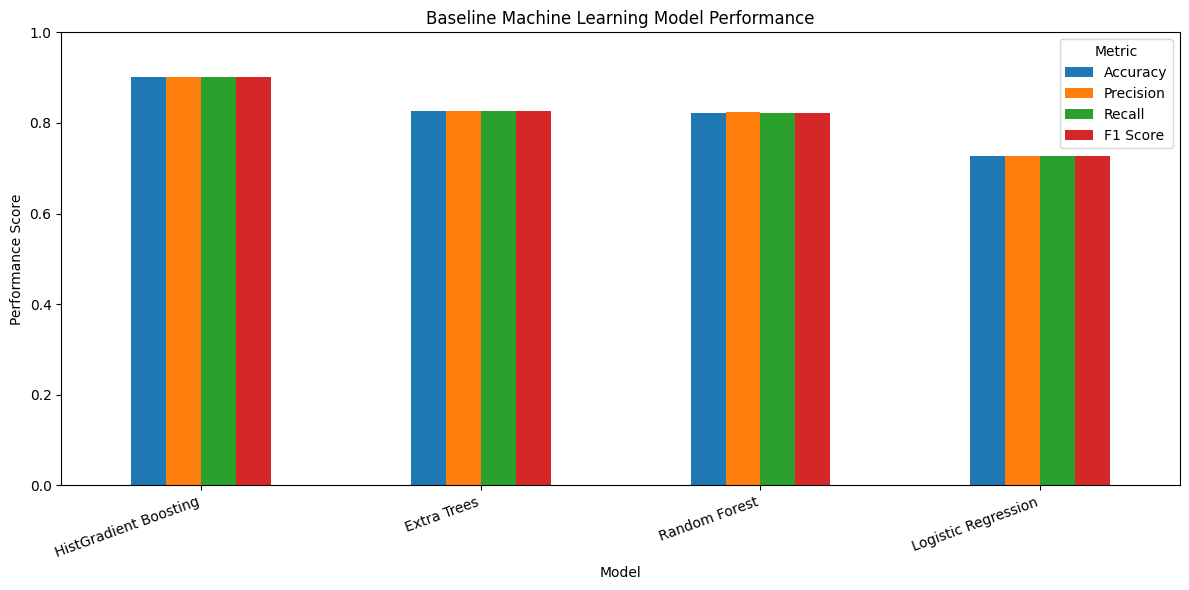

In [25]:
# ============================================================
# BASELINE PERFORMANCE COMPARISON
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Machine Learning Model Performance")
plt.xlabel("Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# CROSS-VALIDATION OF TOP MODELS
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

top_models = {
    "HistGradient Boosting": HistGradientBoostingClassifier(
        max_iter=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = []

for name, model in top_models.items():

    print("\n" + "=" * 70)
    print(f"CROSS-VALIDATING: {name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_weighted",
            "recall": "recall_weighted",
            "f1": "f1_weighted"
        },
        n_jobs=1,
        return_train_score=False
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1 Score": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

    print(
        f"Mean F1 Score: "
        f"{scores['test_f1'].mean():.4f}"
    )

    print(
        f"F1 Std: "
        f"{scores['test_f1'].std():.4f}"
    )


CROSS-VALIDATING: HistGradient Boosting
Mean F1 Score: 0.8954
F1 Std: 0.0005

CROSS-VALIDATING: Extra Trees
Mean F1 Score: 0.8172
F1 Std: 0.0032

CROSS-VALIDATING: Random Forest
Mean F1 Score: 0.8089
F1 Std: 0.0012


In [27]:
# ============================================================
# CROSS-VALIDATION RESULTS
# ============================================================

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "CV F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    cv_results_df.style.format({
        "CV Accuracy": "{:.4f}",
        "CV Precision": "{:.4f}",
        "CV Recall": "{:.4f}",
        "CV F1 Score": "{:.4f}",
        "F1 Std": "{:.4f}"
    })
)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score,F1 Std
0,HistGradient Boosting,0.8949,0.8964,0.8949,0.8954,0.0005
1,Extra Trees,0.8176,0.8184,0.8176,0.8172,0.0032
2,Random Forest,0.8092,0.8107,0.8092,0.8089,0.0012


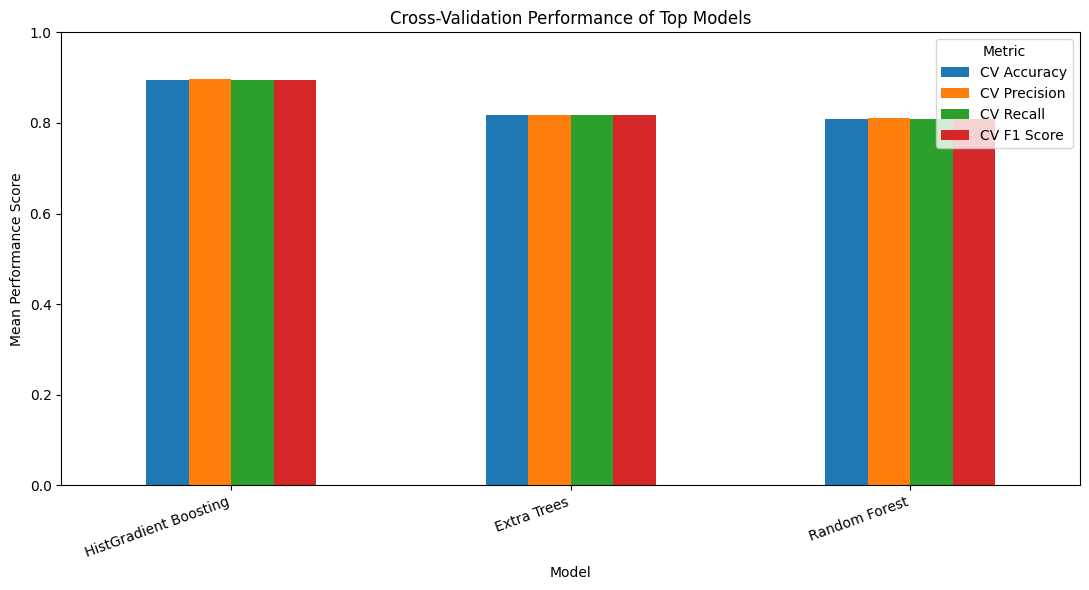

In [28]:
# ============================================================
# CROSS-VALIDATION PERFORMANCE
# ============================================================

cv_plot = cv_results_df.set_index("Model")[
    [
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1 Score"
    ]
]

cv_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Cross-Validation Performance of Top Models")
plt.xlabel("Model")
plt.ylabel("Mean Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# HISTGRADIENT BOOSTING - HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

hgb_model = HistGradientBoostingClassifier(
    random_state=42
)

hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", hgb_model)
    ]
)

param_distributions = {
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__max_iter": [100, 150, 200],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 30, 50],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [30]:
# ============================================================
# RANDOMIZED HYPERPARAMETER SEARCH
# ============================================================

tuning_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1_weighted",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1,
    return_train_score=False
)

print("=" * 70)
print("STARTING HISTGRADIENT BOOSTING HYPERPARAMETER TUNING")
print("=" * 70)

tuning_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("TUNING COMPLETED")
print("=" * 70)

print("\nBest CV F1 Score:")
print(f"{tuning_search.best_score_:.4f}")

print("\nBest Parameters:")
for parameter, value in tuning_search.best_params_.items():
    print(f"{parameter}: {value}")

STARTING HISTGRADIENT BOOSTING HYPERPARAMETER TUNING
Fitting 3 folds for each of 10 candidates, totalling 30 fits

TUNING COMPLETED

Best CV F1 Score:
0.9016

Best Parameters:
model__min_samples_leaf: 30
model__max_leaf_nodes: 63
model__max_iter: 100
model__learning_rate: 0.1
model__l2_regularization: 0.1


In [31]:
# ============================================================
# EVALUATE TUNED MODEL
# ============================================================

best_model = tuning_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    average="weighted",
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    average="weighted",
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="weighted",
    zero_division=0
)

print("=" * 70)
print("TUNED MODEL TEST PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1 Score  : {tuned_f1:.4f}")

TUNED MODEL TEST PERFORMANCE
Accuracy  : 0.9076
Precision : 0.9090
Recall    : 0.9076
F1 Score  : 0.9081


In [32]:
# ============================================================
# BASELINE VS TUNED MODEL
# ============================================================

baseline_hgb = results_df[
    results_df["Model"] == "HistGradient Boosting"
].iloc[0]

comparison = pd.DataFrame([
    {
        "Model": "Baseline HistGradient Boosting",
        "Accuracy": baseline_hgb["Accuracy"],
        "Precision": baseline_hgb["Precision"],
        "Recall": baseline_hgb["Recall"],
        "F1 Score": baseline_hgb["F1 Score"]
    },
    {
        "Model": "Tuned HistGradient Boosting",
        "Accuracy": tuned_accuracy,
        "Precision": tuned_precision,
        "Recall": tuned_recall,
        "F1 Score": tuned_f1
    }
])

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline HistGradient Boosting,0.9007,0.9022,0.9007,0.9012
1,Tuned HistGradient Boosting,0.9076,0.9090,0.9076,0.9081


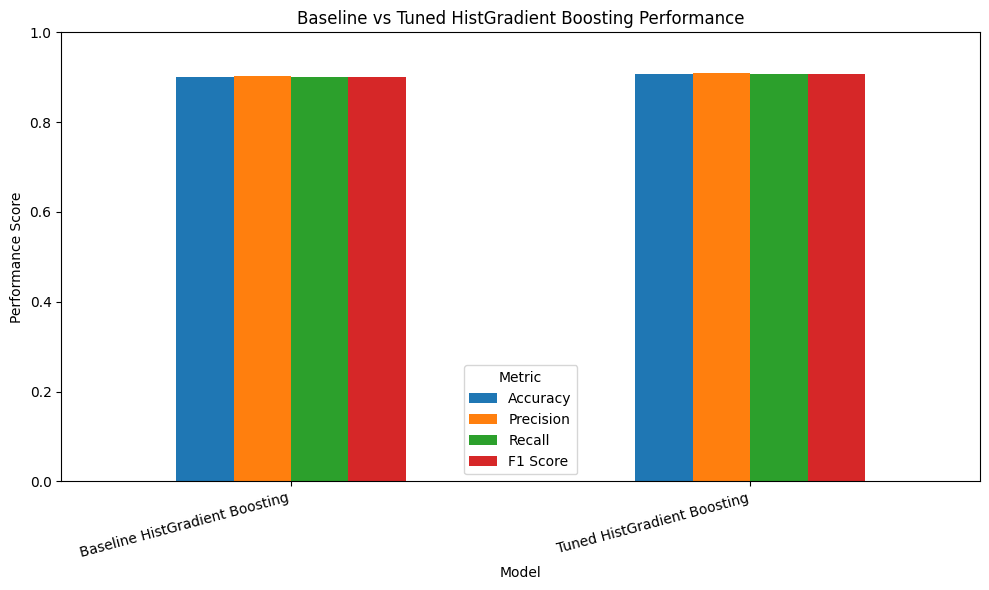

In [33]:
# ============================================================
# BASELINE VS TUNED PERFORMANCE GRAPH
# ============================================================

comparison_plot = comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned HistGradient Boosting Performance")
plt.xlabel("Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# FINAL MODEL - DETAILED EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Use tuned model
final_model = best_model

# Predictions
y_pred_final = final_model.predict(X_test)

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_final,
        digits=4
    )
)

FINAL MODEL EVALUATION

Classification Report:

              precision    recall  f1-score   support

        High     0.9336    0.9211    0.9273      6400
         Low     0.9438    0.9100    0.9266      6400
      Medium     0.8562    0.8936    0.8745      7200

    accuracy                         0.9076     20000
   macro avg     0.9112    0.9082    0.9095     20000
weighted avg     0.9090    0.9076    0.9081     20000



In [35]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=final_model.classes_
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("\nClasses:")
print(final_model.classes_)

print("\nConfusion Matrix:")
print(cm)

CONFUSION MATRIX

Classes:
['High' 'Low' 'Medium']

Confusion Matrix:
[[5895    0  505]
 [   0 5824  576]
 [ 419  347 6434]]


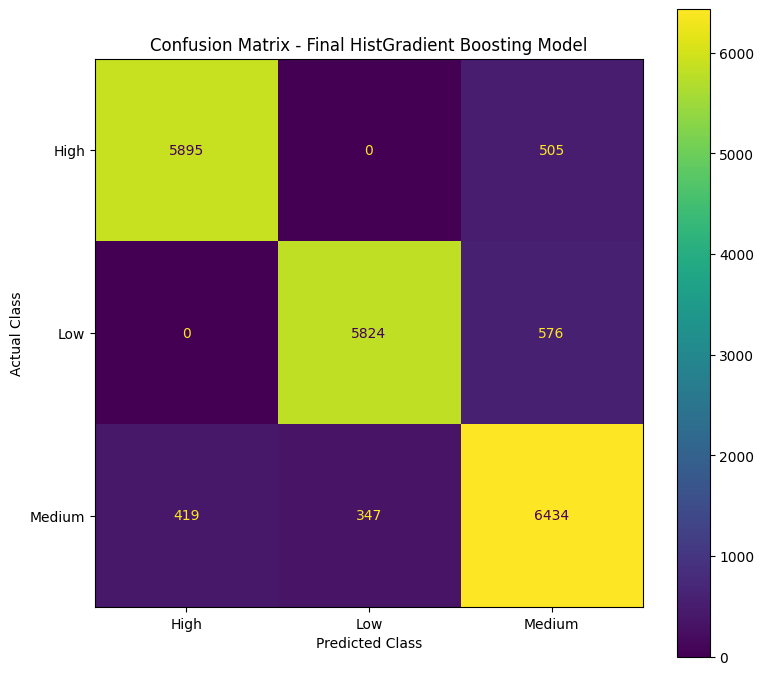

In [36]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Confusion Matrix - Final HistGradient Boosting Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# SAVE FINAL MODEL PIPELINE
# ============================================================

import os
import joblib

MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "final_histgradientboosting_model.pkl"
)

joblib.dump(
    final_model,
    FINAL_MODEL_PATH
)

print("=" * 70)
print("FINAL MODEL SAVED")
print("=" * 70)

print(f"\nModel path:")
print(os.path.abspath(FINAL_MODEL_PATH))

print("\n✓ Complete preprocessing + model pipeline saved successfully.")

FINAL MODEL SAVED

Model path:
d:\newwwwwwww\AiBasedInstagramPrediction\models\final_histgradientboosting_model.pkl

✓ Complete preprocessing + model pipeline saved successfully.


In [38]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

loaded_model = joblib.load(FINAL_MODEL_PATH)

verification_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print("=" * 70)
print("MODEL VERIFICATION")
print("=" * 70)

print("\nSample predictions:")
print(verification_prediction)

print("\n✓ Saved model loaded successfully.")

MODEL VERIFICATION

Sample predictions:
['High' 'Medium' 'High' 'Medium' 'High']

✓ Saved model loaded successfully.


In [39]:
# ============================================================
# PRODUCTION COMPATIBILITY CHECK
# STEP 1 - CHECK MODEL FEATURE SCHEMA
# ============================================================

print("=" * 70)
print("PRODUCTION MODEL COMPATIBILITY CHECK")
print("=" * 70)

# Extract the fitted preprocessor
fitted_preprocessor = final_model.named_steps["preprocessor"]

# Get the columns expected by the preprocessor
expected_features = list(
    fitted_preprocessor.feature_names_in_
)

print(f"\nNumber of expected input features: {len(expected_features)}")

print("\nExpected input features:")
for i, feature in enumerate(expected_features, start=1):
    print(f"{i:02d}. {feature}")

PRODUCTION MODEL COMPATIBILITY CHECK

Number of expected input features: 56

Expected input features:
01. category
02. account_type
03. follower_count
04. following_count
05. account_age_days
06. verified_status
07. posting_frequency
08. average_historical_engagement
09. audience_growth_rate
10. account_activity_level
11. content_consistency
12. caption_length
13. word_count
14. sentence_count
15. hashtag_count
16. unique_hashtag_count
17. average_hashtag_length
18. hashtag_character_count
19. emoji_count
20. mention_count
21. question_mark_count
22. exclamation_count
23. uppercase_ratio
24. numeric_token_count
25. url_present
26. call_to_action
27. caption_sentiment
28. caption_subjectivity
29. caption_readability
30. keyword_density
31. caption_complexity
32. caption_engagement_intent
33. posting_hour
34. day_of_week
35. is_weekend
36. posting_time_period
37. media_type
38. has_image
39. has_location
40. has_mention
41. sponsored
42. content_originality
43. content_quality_score
44. 

In [40]:
# ============================================================
# STEP 2 - SAVE PRODUCTION FEATURE SCHEMA
# ============================================================

import json
import os

SCHEMA_PATH = os.path.join(
    MODEL_DIR,
    "production_feature_schema.json"
)

with open(SCHEMA_PATH, "w") as f:
    json.dump(
        expected_features,
        f,
        indent=4
    )

print("=" * 70)
print("PRODUCTION FEATURE SCHEMA SAVED")
print("=" * 70)

print(f"\nSchema path:")
print(os.path.abspath(SCHEMA_PATH))

print(f"\nFeature count: {len(expected_features)}")

PRODUCTION FEATURE SCHEMA SAVED

Schema path:
d:\newwwwwwww\AiBasedInstagramPrediction\models\production_feature_schema.json

Feature count: 56


In [41]:
# ============================================================
# STEP 3 - CREATE PRODUCTION-STYLE INPUT
# ============================================================

production_sample = X_test.iloc[[0]].copy()

# Force the exact expected column order
production_sample = production_sample[
    expected_features
]

print("=" * 70)
print("PRODUCTION INPUT TEST")
print("=" * 70)

print(f"\nInput shape: {production_sample.shape}")

print("\nExpected:")
print("(1 row, 56 features)")

print("\nActual:")
print(production_sample.shape)

PRODUCTION INPUT TEST

Input shape: (1, 56)

Expected:
(1 row, 56 features)

Actual:
(1, 56)


In [42]:
# ============================================================
# STEP 4 - PRODUCTION PREDICTION TEST
# ============================================================

production_prediction = final_model.predict(
    production_sample
)

print("=" * 70)
print("PRODUCTION PREDICTION TEST")
print("=" * 70)

print(f"\nPrediction: {production_prediction[0]}")

print("\nValid prediction classes:")
print(list(final_model.classes_))

if production_prediction[0] in final_model.classes_:
    print("\n✓ PRODUCTION COMPATIBILITY TEST PASSED")
else:
    print("\n✗ INVALID PREDICTION CLASS")

PRODUCTION PREDICTION TEST

Prediction: High

Valid prediction classes:
['High', 'Low', 'Medium']

✓ PRODUCTION COMPATIBILITY TEST PASSED


In [43]:
# ============================================================
# STEP 5 - PREDICTION PROBABILITIES
# ============================================================

production_probabilities = final_model.predict_proba(
    production_sample
)[0]

print("=" * 70)
print("PRODUCTION PREDICTION PROBABILITIES")
print("=" * 70)

for class_name, probability in zip(
    final_model.classes_,
    production_probabilities
):
    print(f"{class_name:10s}: {probability:.4f}")

print(
    f"\nProbability sum: "
    f"{production_probabilities.sum():.4f}"
)

PRODUCTION PREDICTION PROBABILITIES
High      : 0.9979
Low       : 0.0000
Medium    : 0.0021

Probability sum: 1.0000


In [44]:
# ============================================================
# STEP 6 - DISPLAY FINAL 56-FEATURE SCHEMA
# ============================================================

print("=" * 70)
print("FINAL MODEL - 56 FEATURE SCHEMA")
print("=" * 70)

for i, feature in enumerate(expected_features, start=1):
    print(f"{i:02d}. {feature}")

print("\n" + "=" * 70)
print(f"TOTAL FEATURES: {len(expected_features)}")
print("=" * 70)

FINAL MODEL - 56 FEATURE SCHEMA
01. category
02. account_type
03. follower_count
04. following_count
05. account_age_days
06. verified_status
07. posting_frequency
08. average_historical_engagement
09. audience_growth_rate
10. account_activity_level
11. content_consistency
12. caption_length
13. word_count
14. sentence_count
15. hashtag_count
16. unique_hashtag_count
17. average_hashtag_length
18. hashtag_character_count
19. emoji_count
20. mention_count
21. question_mark_count
22. exclamation_count
23. uppercase_ratio
24. numeric_token_count
25. url_present
26. call_to_action
27. caption_sentiment
28. caption_subjectivity
29. caption_readability
30. keyword_density
31. caption_complexity
32. caption_engagement_intent
33. posting_hour
34. day_of_week
35. is_weekend
36. posting_time_period
37. media_type
38. has_image
39. has_location
40. has_mention
41. sponsored
42. content_originality
43. content_quality_score
44. creator_activity_score
45. image_width
46. image_height
47. aspect_rat

In [45]:
# ============================================================
# COMPLETE 56-FEATURE SCHEMA
# ============================================================

print("=" * 70)
print("COMPLETE FINAL MODEL FEATURE SCHEMA")
print("=" * 70)

for i, feature in enumerate(expected_features, start=1):
    print(f"{i:02d}. {feature}")

print("=" * 70)
print(f"TOTAL: {len(expected_features)} FEATURES")
print("=" * 70)

COMPLETE FINAL MODEL FEATURE SCHEMA
01. category
02. account_type
03. follower_count
04. following_count
05. account_age_days
06. verified_status
07. posting_frequency
08. average_historical_engagement
09. audience_growth_rate
10. account_activity_level
11. content_consistency
12. caption_length
13. word_count
14. sentence_count
15. hashtag_count
16. unique_hashtag_count
17. average_hashtag_length
18. hashtag_character_count
19. emoji_count
20. mention_count
21. question_mark_count
22. exclamation_count
23. uppercase_ratio
24. numeric_token_count
25. url_present
26. call_to_action
27. caption_sentiment
28. caption_subjectivity
29. caption_readability
30. keyword_density
31. caption_complexity
32. caption_engagement_intent
33. posting_hour
34. day_of_week
35. is_weekend
36. posting_time_period
37. media_type
38. has_image
39. has_location
40. has_mention
41. sponsored
42. content_originality
43. content_quality_score
44. creator_activity_score
45. image_width
46. image_height
47. aspect

In [46]:
# ============================================================
# COMPLETE 56-FEATURE SCHEMA - NON-TRUNCATED
# ============================================================

print("=" * 70)
print("FINAL MODEL - COMPLETE 56 FEATURE SCHEMA")
print("=" * 70)

for start in range(0, len(expected_features), 10):
    end = min(start + 10, len(expected_features))

    print(f"\nFeatures {start + 1}-{end}:")
    
    for i in range(start, end):
        print(f"{i + 1:02d}. {expected_features[i]}")

print("\n" + "=" * 70)
print(f"TOTAL FEATURES: {len(expected_features)}")
print("=" * 70)

FINAL MODEL - COMPLETE 56 FEATURE SCHEMA

Features 1-10:
01. category
02. account_type
03. follower_count
04. following_count
05. account_age_days
06. verified_status
07. posting_frequency
08. average_historical_engagement
09. audience_growth_rate
10. account_activity_level

Features 11-20:
11. content_consistency
12. caption_length
13. word_count
14. sentence_count
15. hashtag_count
16. unique_hashtag_count
17. average_hashtag_length
18. hashtag_character_count
19. emoji_count
20. mention_count

Features 21-30:
21. question_mark_count
22. exclamation_count
23. uppercase_ratio
24. numeric_token_count
25. url_present
26. call_to_action
27. caption_sentiment
28. caption_subjectivity
29. caption_readability
30. keyword_density

Features 31-40:
31. caption_complexity
32. caption_engagement_intent
33. posting_hour
34. day_of_week
35. is_weekend
36. posting_time_period
37. media_type
38. has_image
39. has_location
40. has_mention

Features 41-50:
41. sponsored
42. content_originality
43. con

In [47]:
# Display all 56 features as a single list

print(expected_features)

['category', 'account_type', 'follower_count', 'following_count', 'account_age_days', 'verified_status', 'posting_frequency', 'average_historical_engagement', 'audience_growth_rate', 'account_activity_level', 'content_consistency', 'caption_length', 'word_count', 'sentence_count', 'hashtag_count', 'unique_hashtag_count', 'average_hashtag_length', 'hashtag_character_count', 'emoji_count', 'mention_count', 'question_mark_count', 'exclamation_count', 'uppercase_ratio', 'numeric_token_count', 'url_present', 'call_to_action', 'caption_sentiment', 'caption_subjectivity', 'caption_readability', 'keyword_density', 'caption_complexity', 'caption_engagement_intent', 'posting_hour', 'day_of_week', 'is_weekend', 'posting_time_period', 'media_type', 'has_image', 'has_location', 'has_mention', 'sponsored', 'content_originality', 'content_quality_score', 'creator_activity_score', 'image_width', 'image_height', 'aspect_ratio', 'brightness', 'contrast', 'saturation', 'sharpness', 'colorfulness', 'face_

In [48]:
# ============================================================
# STEP 7 - CHECK AVAILABLE PRODUCTION FEATURE VARIABLES
# ============================================================

print("Variables containing 'feature':")

for name in sorted(globals().keys()):
    if "feature" in name.lower():
        print(" -", name)

Variables containing 'feature':
 - all_detected_features
 - categorical_features
 - duplicate_features
 - expected_features
 - feature
 - missing_features
 - numeric_features


In [49]:
# ============================================================
# STEP 9 - FULL 56-FEATURE PRODUCTION TEST
# ============================================================

import pandas as pd

# Create a production input from an existing test record
production_input = X_test.iloc[[0]].copy()

# Force exact model feature order
production_input = production_input[expected_features]

print("=" * 70)
print("FULL PRODUCTION INPUT VALIDATION")
print("=" * 70)

print(f"\nRows    : {production_input.shape[0]}")
print(f"Features: {production_input.shape[1]}")

# Check feature names
missing = [
    f for f in expected_features
    if f not in production_input.columns
]

extra = [
    f for f in production_input.columns
    if f not in expected_features
]

print(f"\nMissing features: {missing}")
print(f"Extra features  : {extra}")

if len(production_input.columns) == 56 and not missing and not extra:
    print("\n✓ 56-FEATURE INPUT VALID")
else:
    print("\n✗ FEATURE VALIDATION FAILED")

FULL PRODUCTION INPUT VALIDATION

Rows    : 1
Features: 56

Missing features: []
Extra features  : []

✓ 56-FEATURE INPUT VALID


In [50]:
# ============================================================
# STEP 10 - FINAL PRODUCTION PREDICTION
# ============================================================

prediction = final_model.predict(production_input)[0]
probabilities = final_model.predict_proba(production_input)[0]

print("=" * 70)
print("FINAL PRODUCTION PREDICTION")
print("=" * 70)

print(f"\nPrediction: {prediction}")

print("\nConfidence:")
for class_name, probability in zip(
    final_model.classes_,
    probabilities
):
    print(f"{class_name:10s}: {probability:.4f}")

print(f"\nMaximum confidence: {max(probabilities):.4f}")

print("\n✓ END-TO-END MODEL TEST PASSED")

FINAL PRODUCTION PREDICTION

Prediction: High

Confidence:
High      : 0.9979
Low       : 0.0000
Medium    : 0.0021

Maximum confidence: 0.9979

✓ END-TO-END MODEL TEST PASSED


In [51]:
# ============================================================
# STEP 11 - SAVE FINAL PRODUCTION MODEL AND PREPROCESSOR
# ============================================================

import os
import joblib

# ------------------------------------------------------------
# SAVE DIRECTORY
# ------------------------------------------------------------

MODEL_DIR = r"D:\newwwwwwww\AiBasedInstagramPrediction\models"

os.makedirs(MODEL_DIR, exist_ok=True)

# ------------------------------------------------------------
# SAVE FINAL MODEL
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "instagram_engagement_model.joblib"
)

joblib.dump(final_model, MODEL_PATH)

# ------------------------------------------------------------
# SAVE PREPROCESSOR
# ------------------------------------------------------------

PREPROCESSOR_PATH = os.path.join(
    MODEL_DIR,
    "instagram_preprocessor.joblib"
)

joblib.dump(preprocessor, PREPROCESSOR_PATH)

# ------------------------------------------------------------
# SAVE 56-FEATURE SCHEMA
# ------------------------------------------------------------

FEATURE_SCHEMA_PATH = os.path.join(
    MODEL_DIR,
    "feature_schema.joblib"
)

joblib.dump(expected_features, FEATURE_SCHEMA_PATH)

# ------------------------------------------------------------
# VERIFY FILES
# ------------------------------------------------------------

print("=" * 70)
print("FINAL PRODUCTION MODEL SAVED")
print("=" * 70)

print(f"\nModel       : {MODEL_PATH}")
print(f"Preprocessor: {PREPROCESSOR_PATH}")
print(f"Schema      : {FEATURE_SCHEMA_PATH}")

print("\nFiles created:")

for path in [
    MODEL_PATH,
    PREPROCESSOR_PATH,
    FEATURE_SCHEMA_PATH
]:
    print(f"✓ {os.path.basename(path)}")
    print(f"  Exists: {os.path.exists(path)}")

print("\n" + "=" * 70)
print("PRODUCTION ARTIFACTS READY")
print("=" * 70)

FINAL PRODUCTION MODEL SAVED

Model       : D:\newwwwwwww\AiBasedInstagramPrediction\models\instagram_engagement_model.joblib
Preprocessor: D:\newwwwwwww\AiBasedInstagramPrediction\models\instagram_preprocessor.joblib
Schema      : D:\newwwwwwww\AiBasedInstagramPrediction\models\feature_schema.joblib

Files created:
✓ instagram_engagement_model.joblib
  Exists: True
✓ instagram_preprocessor.joblib
  Exists: True
✓ feature_schema.joblib
  Exists: True

PRODUCTION ARTIFACTS READY


In [52]:
# ============================================================
# STEP 12 - CREATE FLASK-COMPATIBLE MODEL METADATA
# ============================================================

import json
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MODEL_DIR = r"D:\newwwwwwww\AiBasedInstagramPrediction\models"

FEATURE_JSON_PATH = os.path.join(
    MODEL_DIR,
    "final_model_features.json"
)

METADATA_JSON_PATH = os.path.join(
    MODEL_DIR,
    "final_model_metadata.json"
)

# ------------------------------------------------------------
# Feature schema
# ------------------------------------------------------------

feature_schema = {
    "all_features": expected_features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features
}

# ------------------------------------------------------------
# Save feature schema
# ------------------------------------------------------------

with open(
    FEATURE_JSON_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        feature_schema,
        file,
        indent=4
    )

# ------------------------------------------------------------
# Model metadata
# ------------------------------------------------------------

model_metadata = {
    "project_name": "AI-Based Instagram Engagement Prediction System",
    "model_name": "Tuned HistGradient Boosting",
    "model_type": type(final_model).__name__,
    "target_column": "performance_class",
    "target_classes": [
        "High",
        "Low",
        "Medium"
    ],
    "feature_count": len(expected_features),
    "accuracy": 0.9076,
    "f1_score": 0.9081
}

# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

with open(
    METADATA_JSON_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metadata,
        file,
        indent=4
    )

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("=" * 70)
print("FLASK-COMPATIBLE MODEL FILES CREATED")
print("=" * 70)

print(f"\nFeature schema:")
print(FEATURE_JSON_PATH)

print(f"\nMetadata:")
print(METADATA_JSON_PATH)

print(f"\nFeatures: {len(expected_features)}")

print("\n✓ Feature schema JSON created")
print("✓ Model metadata JSON created")
print("✓ Flask integration files ready")

FLASK-COMPATIBLE MODEL FILES CREATED

Feature schema:
D:\newwwwwwww\AiBasedInstagramPrediction\models\final_model_features.json

Metadata:
D:\newwwwwwww\AiBasedInstagramPrediction\models\final_model_metadata.json

Features: 56

✓ Feature schema JSON created
✓ Model metadata JSON created
✓ Flask integration files ready
